In [30]:
from pydantic import BaseModel 
from langgraph.graph import StateGraph, START, END

In [31]:
class GreetState(BaseModel) : 
    message : str = ""

In [32]:
graph = StateGraph(GreetState)

#### Nodes - Python Functions

In [33]:
def Greet(state: GreetState) : 
    state.message = f"{state.message} ! Hello, How are you?"
    return state

def upperCase(state : GreetState) : 
    state.message = state.message.upper()
    return state

In [34]:
graph.add_node("greet" , Greet)

In [35]:
graph.add_node("upper_case", upperCase)

In [36]:
graph.add_edge(START, "greet")
graph.add_edge("greet", "upper_case")
graph.add_edge("upper_case", END)

In [37]:
finalGraph = graph.compile()

In [38]:
res = finalGraph.invoke({"message" : "I Like Langgraph"})

In [39]:
res

{'message': 'I LIKE LANGGRAPH ! HELLO, HOW ARE YOU?'}

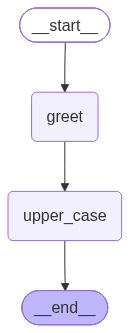

In [40]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())